(12)=
# Chapter 12: Polynomial Fitting & Interpolation

**Topics Covered:**
- Motivation: fitting heat capacity $C_p(T)$ from NIST tabulated data for CO$_2$
- Polynomial basics: `np.poly1d`, `np.polyval`, `np.polyfit`
- Least-squares polynomial fitting: choosing the right degree, residuals, $R^2$
- Taylor series: definition, convergence, and ChE linearization
- Polynomial interpolation: Lagrange method and Runge's phenomenon
- Spline interpolation: `CubicSpline`, `interp1d`, and steam table application

---
## 📋 Lecture Script

Good [morning/afternoon] everyone. Today we're in Chapter 12 — **Polynomial Fitting and Interpolation**. This is one of the most practically useful chapters in the course because these techniques come up constantly in real engineering work.


Alright everyone, let’s talk about polynomials.

A polynomial is one of the most fundamental objects in mathematics, especially in algebra, calculus, and engineering models.

Definition

A polynomial is an expression made of:
- variables (like x)
- coefficients (numbers)
- exponents that are non-negative integers
- addition, subtraction, and multiplication only


The big picture: experimental data and published tables always give you numbers at *specific* conditions. But in design calculations, you almost never need the function at *exactly* those conditions — you need it at some arbitrary intermediate point, or you need to integrate it, or differentiate it. Polynomials let you convert discrete data into a continuous mathematical model you can do calculus on.

By the end of today you'll know how to:
- Fit a polynomial to noisy data and evaluate it at any point
- Use Taylor series to linearize nonlinear functions like Arrhenius
- Interpolate through tabulated data without introducing artifacts
- Apply all of this to real ChE problems — heat capacity, steam tables, reaction kinetics

Let's start with the motivating problem.

In [3]:
# ── All imports ─────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, CubicSpline, interp1d
from scipy.special import factorial

(12.1)=
## 12.1 Motivation: Heat Capacity of CO$_2$

In chemical engineering, we frequently need $C_p(T)$ — the molar heat capacity as a function of temperature — to compute:

$$
Q = n \int_{T_1}^{T_2} C_p(T)\, dT
$$

NIST publishes $C_p$ in tabulated form at discrete temperatures. Before we can integrate, we need a **continuous mathematical model** — a polynomial — that passes smoothly through the data.

Below is a subset of NIST data for CO$_2$ (ideal gas, J mol$^{-1}$ K$^{-1}$):

| $T$ (K) | $C_p$ (J mol$^{-1}$ K$^{-1}$) |
|---------|-------------------------------|
| 300     | 37.13                         |
| 400     | 41.33                         |
| 500     | 44.60                         |
| 600     | 47.33                         |
| 700     | 49.65                         |
| 800     | 51.61                         |
| 900     | 53.26                         |
| 1000    | 54.31                         |
| 1100    | 55.37                         |
| 1200    | 56.21                         |

We want to fit $C_p(T) \approx a_0 + a_1 T + a_2 T^2 + \cdots$ so we can evaluate it at any temperature and integrate it analytically.

### 🎙️ Script — 12.1

Here's the problem. NIST publishes molar heat capacity data for CO₂ at discrete temperatures — 300 K, 400 K, 500 K, up to 1200 K. Ten data points total.

Now suppose you're designing a heat exchanger and need:

$$Q = n \int_{400}^{900} C_p(T)\, dT$$

You **cannot** integrate a table of numbers directly — you need a *function*. That's what polynomial fitting gives you.

*(Run the plot cell — show the data points)*

Notice the trend: $C_p$ increases with temperature and starts leveling off. It's clearly not linear, but it's smooth and monotonic — a classic candidate for a low-degree polynomial fit.

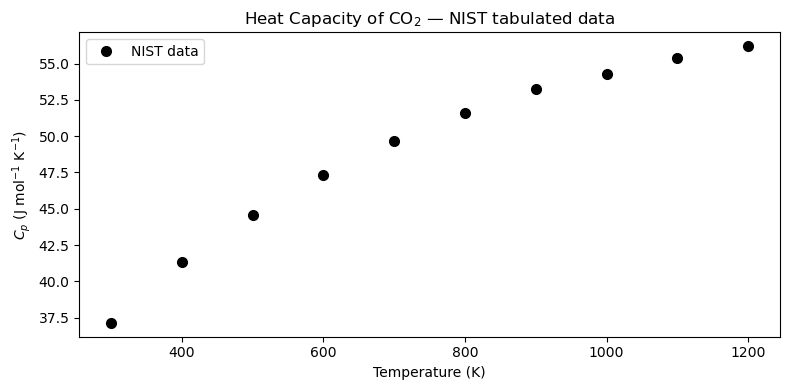

In [4]:

# NIST tabulated Cp data for CO2 (ideal gas)
T_data  = np.array([300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200], dtype=float)  # K
Cp_data = np.array([37.13, 41.33, 44.60, 47.33, 49.65,
                    51.61, 53.26, 54.31, 55.37, 56.21])  # J/(mol K)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(T_data, Cp_data, 'ko', markersize=7, label='NIST data')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$C_p$ (J mol$^{-1}$ K$^{-1}$)')
ax.set_title(r'Heat Capacity of CO$_2$ — NIST tabulated data')
ax.legend()
plt.tight_layout()
plt.show()

(12.2)=
## 12.2 Polynomial Basics

A degree-$n$ polynomial is:

$$
p(x) = a_n x^n + a_{n-1} x^{n-1} + \cdots + a_1 x + a_0
$$

NumPy stores polynomial coefficients in **descending order** (highest power first). Three key tools:

| Function | Purpose |
|----------|---------|
| `np.poly1d(coeffs)` | Create a callable polynomial object |
| `np.polyval(coeffs, x)` | Evaluate polynomial at $x$ |
| `np.polyfit(x, y, deg)` | Least-squares fit: returns coefficients |

**Convention:** `coeffs = [a_n, a_{n-1}, ..., a_1, a_0]` — highest power first.

---

### The coefficient array

Say you have $p(x) = 3x^2 + 5x - 2$. NumPy represents this as `[3, 5, -2]`:

```
index:  0    1    2
value: [3,   5,  -2]
         ↑    ↑    ↑
        x²   x¹   x⁰
```

### `np.poly1d(coeffs)` — callable polynomial object

Wraps the coefficient list into an object you can call like a function:
```python
p = np.poly1d([3, 5, -2])
p(1)   # → 3(1)² + 5(1) - 2 = 6
p(0)   # → -2
```
Bonus methods: `p.deriv()` (derivative), `p.integ()` (integral), `p.roots` (zeros).

### `np.polyval(coeffs, x)` — evaluate from the list directly

Same result, no object needed. Works on scalars or arrays:
```python
np.polyval([3, 5, -2], 1)           # → 6
np.polyval([3, 5, -2], [0, 1, 2])   # → [-2, 6, 20]
```
Use this when you only need values and don't need derivatives/integrals.

### `np.polyfit(x, y, deg)` — find best-fit coefficients

Given data points, returns a coefficient array in the same descending convention:
```python
coeffs = np.polyfit(x_data, y_data, deg=3)  # fit  → coeffs
p      = np.poly1d(coeffs)                  # wrap → callable
y_fit  = p(x_fine)                          # evaluate on dense grid
# or equivalently:
y_fit  = np.polyval(coeffs, x_fine)
```

Use `poly1d` when you also need `.deriv()` / `.integ()` / `.roots`; use `polyval` when you just need numbers.

### 🎙️ Script — 12.2

Before we fit anything, let's nail down the three NumPy tools you'll use for every polynomial calculation in this course.

**The coefficient convention** — this is where people get tripped up.

NumPy stores coefficients in *descending* power order. For $p(x) = 3x^2 + 5x - 2$, NumPy wants `[3, 5, -2]`. Index 0 = highest power, last index = constant. **Highest power first.**

**`np.poly1d(coeffs)`** wraps a list into a callable object. Its bonus: `.deriv()`, `.integ()`, `.roots`. Use it when you need calculus operations.

**`np.polyval(coeffs, x)`** evaluates directly from a list — works on scalars or arrays. Use it when you just need numbers.

**`np.polyfit(x, y, deg)`** — the workhorse. Give it data and a degree, it returns best-fit coefficients in that same descending convention.

*(Run the demo cell — point out the pretty-printed poly1d output, the evaluation table showing all three methods agree, then the derivative `6x + 5`, the antiderivative, and the roots)*

The fact that all three methods — `poly1d`, `polyval`, and manual — give identical results is a good sanity check to run whenever you're unsure.

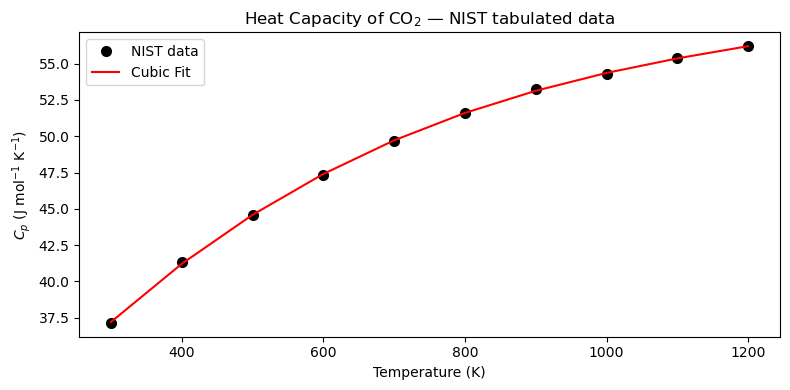

In [5]:

# NIST tabulated Cp data for CO2 (ideal gas)
T_data  = np.array([300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200], dtype=float)  # K
Cp_data = np.array([37.13, 41.33, 44.60, 47.33, 49.65,
                    51.61, 53.26, 54.31, 55.37, 56.21])  # J/(mol K)

coefficients = np.polyfit(T_data, Cp_data, deg=3)  # returns coefficients of cubic fit
Cp_fit = np.polyval(coefficients, T_data)  # evaluate cubic fit at T_data points


fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(T_data, Cp_data, 'ko', markersize=7, label='NIST data')
ax.plot(T_data, Cp_fit, 'r-', label='Cubic Fit')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$C_p$ (J mol$^{-1}$ K$^{-1}$)')
ax.set_title(r'Heat Capacity of CO$_2$ — NIST tabulated data')
ax.legend()
plt.tight_layout()
plt.show()

In [3]:
# ── Coefficient convention demo ───────────────────────────────────────────
# p(x) = 3x² + 5x - 2   →   coeffs = [3, 5, -2]  (descending order)
coeffs_demo = [3, 5, -2]

p_demo = np.poly1d(coeffs_demo)
print("poly1d pretty-print:")
print(p_demo)

# Evaluate at a few points
xs = [0, 1, 2]
print("\nx   poly1d   polyval   manual")
for x in xs:
    manual = 3*x**2 + 5*x - 2
    print(f"{x}   {p_demo(x):6.1f}   {np.polyval(coeffs_demo, x):6.1f}   {manual:6.1f}")

# polyval works on arrays too
print("\npolyval on array [0,1,2]:", np.polyval(coeffs_demo, xs))

# Derivative and integral via poly1d
print("\nDerivative p'(x):")
print(p_demo.deriv())
print("Indefinite integral ∫p dx (+ C):")
print(p_demo.integ())
print("Roots (p(x)=0):", p_demo.roots.round(4))


poly1d pretty-print:
   2
3 x + 5 x - 2

x   poly1d   polyval   manual
0     -2.0     -2.0     -2.0
1      6.0      6.0      6.0
2     20.0     20.0     20.0

polyval on array [0,1,2]: [-2  6 20]

Derivative p'(x):
 
6 x + 5
Indefinite integral ∫p dx (+ C):
   3       2
1 x + 2.5 x - 2 x
Roots (p(x)=0): [-2.      0.3333]


In [4]:
# Define p(x) = 2x^3 - 3x^2 + x - 5  (coefficients in descending order)
coeffs = [2, -3, 1, -5]

p = np.poly1d(coeffs)
print("Polynomial p(x):")
print(p)

# Evaluate at x = 2
x_val = 2.0
print(f"\np({x_val}) using poly1d  : {p(x_val):.4f}")
print(f"p({x_val}) using polyval : {np.polyval(coeffs, x_val):.4f}")
# Manual: 2(8) - 3(4) + 1(2) - 5 = 16 - 12 + 2 - 5 = 1
print(f"Manual check          : {2*x_val**3 - 3*x_val**2 + 1*x_val - 5:.4f}")

Polynomial p(x):
   3     2
2 x - 3 x + 1 x - 5

p(2.0) using poly1d  : 1.0000
p(2.0) using polyval : 1.0000
Manual check          : 1.0000


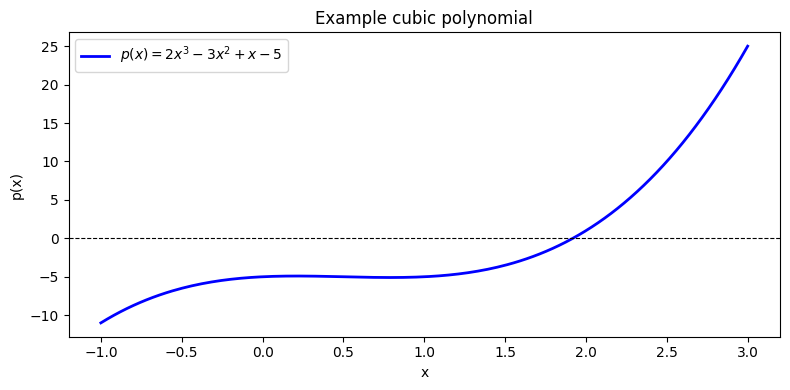

In [5]:
# Plot the polynomial over [-1, 3]
x = np.linspace(-1, 3, 200)
y = np.polyval(coeffs, x)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, 'b-', linewidth=2, label=r'$p(x) = 2x^3 - 3x^2 + x - 5$')
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title('Example cubic polynomial')
ax.legend()
plt.tight_layout()
plt.show()

(12.3)=
## 12.3 Least-Squares Polynomial Fitting

**`np.polyfit(x, y, deg)`** finds the degree-`deg` polynomial coefficients that minimize the sum of squared residuals:

$$
\min_{a_0, \ldots, a_n} \sum_{i=1}^{N} \left[ y_i - p(x_i) \right]^2
$$

This is ordinary least squares applied to a polynomial basis. The function returns coefficients in descending order (highest power first), just like `np.poly1d` expects.

### 🎙️ Script — 12.3

`np.polyfit` solves a least-squares problem:

$$\min_{a_0,\ldots,a_n} \sum_{i=1}^{N} [y_i - p(x_i)]^2$$

This is ordinary least squares applied to a polynomial basis. NumPy sets up the Vandermonde matrix and does the linear algebra internally — you just specify the degree.

(12.3.1)=
### 12.3.1 Fitting Cp(T) with Different Degrees

We fit the CO$_2$ data with degree 1, 2, and 3 polynomials and compare the results visually.

### 🎙️ Script — 12.3.1

*(Run the plot cell — three curves: linear (red), quadratic (orange), cubic (blue) over the NIST data)*

The **linear fit** clearly doesn't capture the curvature — it underestimates in the middle and is off at both ends. The **quadratic** is much better. The **cubic** hugs the data very tightly.

But 'looks good visually' isn't enough — we need numbers.

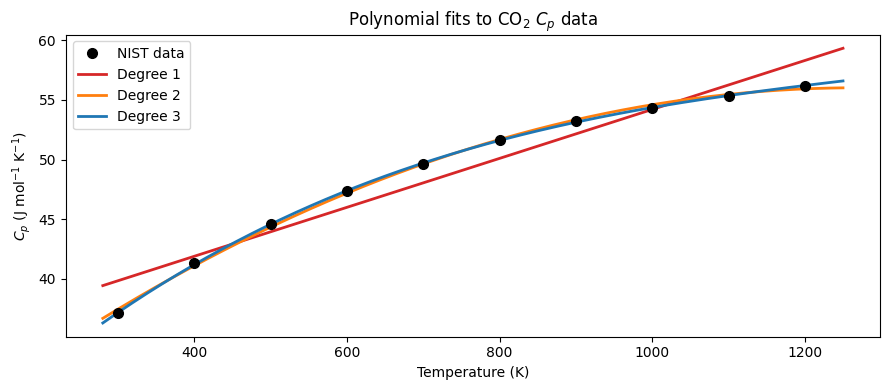

In [6]:
# ── Fit Cp(T) with degree 1, 2, 3 polynomials ────────────────────────────────
T_fine  = np.linspace(280, 1250, 300)
degrees = [1, 2, 3]
colors  = ['tab:red', 'tab:orange', 'tab:blue']
fits    = {}    # store coefficient arrays keyed by degree

for deg in degrees:
    fits[deg] = np.polyfit(T_data, Cp_data, deg)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(T_data, Cp_data, 'ko', markersize=7, zorder=5, label='NIST data')
for deg, color in zip(degrees, colors):
    ax.plot(T_fine, np.polyval(fits[deg], T_fine),
            color=color, linewidth=2, label=f'Degree {deg}')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$C_p$ (J mol$^{-1}$ K$^{-1}$)')
ax.set_title(r'Polynomial fits to CO$_2$ $C_p$ data')
ax.legend()
plt.tight_layout()
plt.show()

(12.3.2)=
### 12.3.2 Residuals and the Coefficient of Determination $R^2$

The **residual** at each data point is:

$$
e_i = y_i - p(x_i)
$$

The **coefficient of determination** $R^2$ measures how much variance the model explains:

$$
R^2 = 1 - \frac{\text{SS}_{\rm res}}{\text{SS}_{\rm tot}}, \qquad
\text{SS}_{\rm res} = \sum_i e_i^2, \qquad
\text{SS}_{\rm tot} = \sum_i (y_i - \bar{y})^2
$$

$R^2 = 1$ is a perfect fit; $R^2$ near 0 means the model explains almost nothing.

### 🎙️ Script — 12.3.2

*(Run the R² table cell — show the printed table)*

Going from degree 1 to 2 cuts the RMSE by a factor of 7. Degree 2 to 3 is another factor of 3. At degree 3 we're down to 0.07 J/(mol·K) — excellent for engineering purposes.

*(Run the residuals stem-plot cell — three panels)*

Now look at the residual *patterns*. The linear residuals curve systematically — the model structure is wrong. The quadratic residuals are smaller but still show a faint pattern. The cubic residuals look like **random scatter around zero** — no systematic trend. That's the hallmark of a well-specified model: the residuals contain no remaining structure.

In [7]:
# ── R² and RMSE for each degree ──────────────────────────────────────────────
SS_tot = np.sum((Cp_data - np.mean(Cp_data))**2)

print(f"{'Degree':>6}  {'RMSE (J/mol/K)':>16}  {'R²':>8}")
print("-" * 36)
for deg in degrees:
    Cp_pred   = np.polyval(fits[deg], T_data)
    residuals = Cp_data - Cp_pred
    SS_res    = np.sum(residuals**2)
    R2        = 1.0 - SS_res / SS_tot
    RMSE      = np.sqrt(np.mean(residuals**2))
    print(f"{deg:>6}  {RMSE:>16.6f}  {R2:>8.6f}")

Degree    RMSE (J/mol/K)        R²
------------------------------------
     1          1.454003  0.942543
     2          0.208613  0.998817
     3          0.069648  0.999868


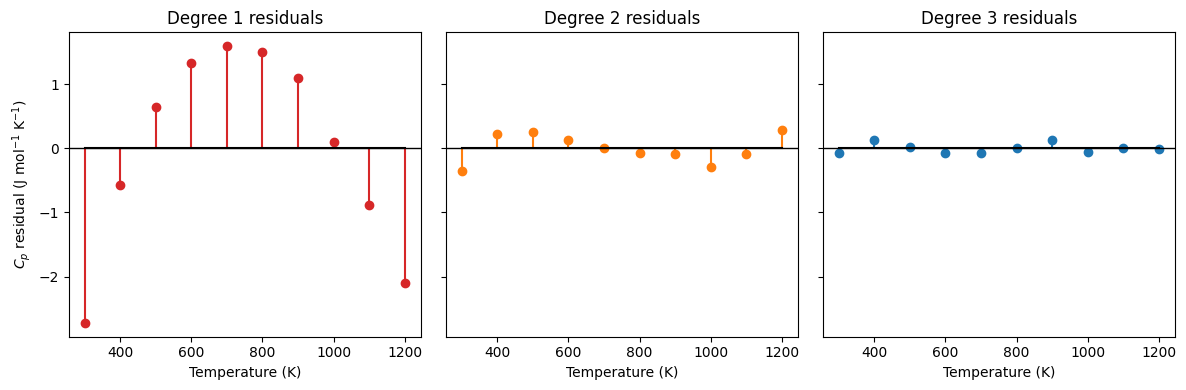

In [8]:
# ── Residual stem plots for each degree ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, deg, color in zip(axes, degrees, colors):
    Cp_pred   = np.polyval(fits[deg], T_data)
    residuals = Cp_data - Cp_pred
    ax.stem(T_data, residuals, linefmt=color, markerfmt='o', basefmt='k-')
    ax.axhline(0, color='k', linewidth=1)
    ax.set_xlabel('Temperature (K)')
    ax.set_title(f'Degree {deg} residuals')

axes[0].set_ylabel(r'$C_p$ residual (J mol$^{-1}$ K$^{-1}$)')
plt.tight_layout()
plt.show()

(12.3.3)=
### 12.3.3 Overfitting: When Higher Degree Hurts

Adding more polynomial terms always reduces training error, but can create **overfitting**: the polynomial wiggles between data points and performs poorly outside the training range.

Here we deliberately use degree 9 (with only 10 data points) to illustrate the problem.

### 🎙️ Script — 12.3.3

Important warning before we move on.

More polynomial terms *always* reduces training error. That does not mean the model is better.

*(Run the overfitting cell — show degree-3 vs degree-9)*

With 10 data points and a degree-9 polynomial, $R^2 = 1.000$ — perfect fit. But look at what happens between the data points and especially outside the training range: **wild oscillations**. The model has memorized the data rather than learned the underlying trend.

For smooth physical properties like $C_p$, degree 2–4 is almost always the right choice. Use $R^2$ and visual residual inspection to pick the degree — not just minimum training error.

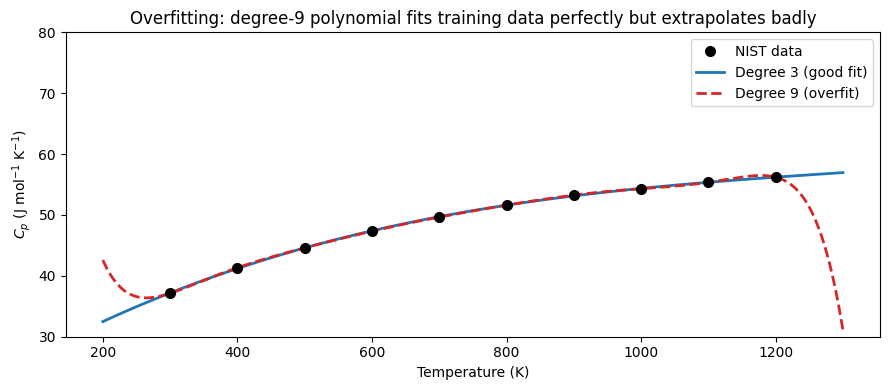

Lesson: For smooth physical data, a low-degree polynomial (2-4) is usually best.
Use R² and visual inspection — not just training error — to choose degree.


In [9]:
# ── Overfitting demonstration ─────────────────────────────────────────────────
coeffs_deg3 = np.polyfit(T_data, Cp_data, 3)
coeffs_deg9 = np.polyfit(T_data, Cp_data, 9)

T_ext = np.linspace(200, 1300, 400)   # extend beyond the data range

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(T_data, Cp_data, 'ko', markersize=7, zorder=5, label='NIST data')
ax.plot(T_ext, np.polyval(coeffs_deg3, T_ext),
        'tab:blue', linewidth=2, label='Degree 3 (good fit)')
ax.plot(T_ext, np.polyval(coeffs_deg9, T_ext),
        'tab:red',  linewidth=2, linestyle='--', label='Degree 9 (overfit)')
ax.set_ylim(30, 80)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$C_p$ (J mol$^{-1}$ K$^{-1}$)')
ax.set_title('Overfitting: degree-9 polynomial fits training data perfectly but extrapolates badly')
ax.legend()
plt.tight_layout()
plt.show()

print("Lesson: For smooth physical data, a low-degree polynomial (2-4) is usually best.")
print("Use R² and visual inspection — not just training error — to choose degree.")

(12.3.4)=
### 12.3.4 Using the Fit: Integrating $C_p$ Analytically

With the degree-3 fit in hand, we integrate $C_p(T)$ to compute the enthalpy change:

$$
\Delta H = n \int_{T_1}^{T_2} C_p(T)\, dT
$$

`np.poly1d` exposes a `.integ()` method that returns the antiderivative polynomial.

### 🎙️ Script — 12.3.4

Now back to the original problem. With the degree-3 fit in hand, `.integ()` gives the antiderivative polynomial instantly:

*(Run the integration cell)*

```
Degree-3 Cp polynomial:
1.119e-08 x³ - 4.498e-05 x² + 0.06745 x + 20.71

ΔH = 24067.83 J/mol = 24.07 kJ/mol
```

That's the enthalpy required to heat 1 mole of CO₂ from 400 K to 900 K — a number you plug directly into an energy balance. The whole workflow: `polyfit` → `poly1d` → `.integ()` → evaluate the definite integral.

In [10]:
# ── Integrate Cp from T1 to T2 using the degree-3 fit ────────────────────────
p3 = np.poly1d(np.polyfit(T_data, Cp_data, 3))
P3 = p3.integ()            # antiderivative (integration constant = 0)

T1, T2 = 400.0, 900.0      # K
dH = P3(T2) - P3(T1)       # J/mol

print("Degree-3 Cp polynomial fit:")
print(p3)
print(f"\nIntegral of Cp from {T1:.0f} K to {T2:.0f} K:")
print(f"  Delta_H = {dH:.2f} J/mol  =  {dH/1000:.4f} kJ/mol")

Degree-3 Cp polynomial fit:
           3             2
1.119e-08 x - 4.498e-05 x + 0.06745 x + 20.71

Integral of Cp from 400 K to 900 K:
  Delta_H = 24067.83 J/mol  =  24.0678 kJ/mol


(12.4)=
## 12.4 Taylor Series

A **Taylor series** expresses a smooth function as an infinite polynomial centered at a point $a$:

$$
f(x) = \sum_{n=0}^{\infty} \frac{f^{(n)}(a)}{n!}\,(x - a)^n
= f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a)^2 + \frac{f'''(a)}{3!}(x-a)^3 + \cdots
$$

Truncating after $N$ terms gives an **$N$-th order approximation**. The key Maclaurin series (centered at $a = 0$) are:

$$
e^x = \sum_{n=0}^{\infty} \frac{x^n}{n!} = 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \cdots
\qquad (\text{converges for all } x)
$$

$$
\sin x = \sum_{k=0}^{\infty} \frac{(-1)^k x^{2k+1}}{(2k+1)!} = x - \frac{x^3}{6} + \frac{x^5}{120} - \cdots
\qquad (\text{converges for all } x)
$$

### 🎙️ Script — 12.4

Taylor series are a different flavor of polynomial approximation. Instead of fitting noisy data, they're **exact** expansions of a known smooth function.

The two series you should have memorized by the end of this course:
- $e^x = 1 + x + x^2/2! + x^3/3! + \cdots$ — converges everywhere
- $\sin x = x - x^3/6 + x^5/120 - \cdots$ — converges everywhere

The key insight: truncating after $N$ terms gives a polynomial approximation that's accurate near the expansion point $a$.

(12.4.1)=
### 12.4.1 Convergence of Partial Sums

We build the partial sums term by term and watch the approximation converge to the exact function as more terms are included.

### 🎙️ Script — 12.4.1

*(Run the convergence plots cell)*

Watch $e^x$ on the left: one term is just the constant 1, two terms give a line, three give a parabola — each addition converges toward the true curve. By 5–6 terms we're essentially exact on $[-2, 2]$.

*(Run the numerical convergence table for $e^1$)*

Starting from error = 1.72 with 1 term, down to $3 \times 10^{-7}$ with 10 terms. The error drops roughly geometrically — each new term divides it by 5–10. This rapid convergence is why Taylor series are so powerful for analytic functions.

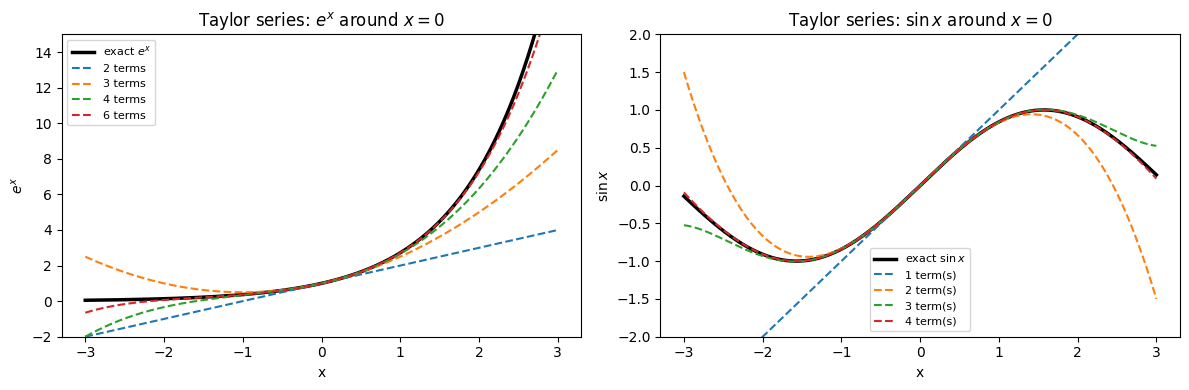

In [11]:
# ── Taylor partial sums: exp(x) and sin(x) ──────────────────────────────────
x = np.linspace(-3, 3, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# -- exp(x) --
ax = axes[0]
ax.plot(x, np.exp(x), 'k-', linewidth=2.5, label='exact $e^x$')
approx = np.zeros_like(x)
for n in range(7):
    approx = approx + x**n / factorial(n)
    if n in [1, 2, 3, 5]:
        ax.plot(x, approx, linestyle='--', linewidth=1.5, label=f'{n+1} terms')
ax.set_ylim(-2, 15)
ax.set_xlabel('x')
ax.set_ylabel(r'$e^x$')
ax.set_title(r'Taylor series: $e^x$ around $x=0$')
ax.legend(fontsize=8)

# -- sin(x) --
ax = axes[1]
ax.plot(x, np.sin(x), 'k-', linewidth=2.5, label=r'exact $\sin x$')
approx = np.zeros_like(x)
for k in range(5):
    n      = 2*k + 1
    sign   = (-1)**k
    approx = approx + sign * x**n / factorial(n)
    if k in [0, 1, 2, 3]:
        ax.plot(x, approx, linestyle='--', linewidth=1.5, label=f'{k+1} term(s)')
ax.set_ylim(-2, 2)
ax.set_xlabel('x')
ax.set_ylabel(r'$\sin x$')
ax.set_title(r'Taylor series: $\sin x$ around $x=0$')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
# ── Numerical convergence: error vs number of terms for exp(1) ───────────────
exact = np.e
print(f"Exact e = {exact:.10f}\n")
print(f"{'N terms':>8}  {'Approximation':>16}  {'Abs Error':>12}")
print("-" * 42)

approx = 0.0
for n in range(10):
    approx += 1.0**n / factorial(n)
    print(f"{n+1:>8}  {approx:>16.10f}  {abs(approx - exact):>12.2e}")

Exact e = 2.7182818285

 N terms     Approximation     Abs Error
------------------------------------------
       1      1.0000000000      1.72e+00
       2      2.0000000000      7.18e-01
       3      2.5000000000      2.18e-01
       4      2.6666666667      5.16e-02
       5      2.7083333333      9.95e-03
       6      2.7166666667      1.62e-03
       7      2.7180555556      2.26e-04
       8      2.7182539683      2.79e-05
       9      2.7182787698      3.06e-06
      10      2.7182815256      3.03e-07


(12.4.2)=
### 12.4.2 ChE Application: Linearizing the Arrhenius Equation

The Arrhenius rate constant is nonlinear in temperature:

$$
k(T) = A \exp\!\left(-\frac{E_a}{RT}\right)
$$

Applying a first-order Taylor expansion around a reference temperature $T_0$:

$$
k(T) \approx k(T_0) + k'(T_0)\,(T - T_0),
\qquad k'(T_0) = k(T_0) \cdot \frac{E_a}{R T_0^2}
$$

This **linearization** is widely used in reactor stability analysis and temperature control design. It is accurate for small deviations $|T - T_0|$ but degrades further from $T_0$.

### 🎙️ Script — 12.4.2

Here's where Taylor linearization appears constantly in ChE: the Arrhenius rate constant.

The first-order Taylor expansion around $T_0$ gives:

$$k(T) \approx k(T_0) + k(T_0)\frac{E_a}{RT_0^2}(T - T_0)$$

This is used in reactor stability analysis and temperature control design — anywhere you need a linear model of reaction rate.

*(Run the Arrhenius cell — show the plot and error table)*

At $\pm 10$ K from $T_0$, the linearization is within a couple percent — good enough for control design. At $\pm 50$ K, the error grows substantially. This is why reactor models always specify 'valid for small deviations from steady state' — they mean exactly this first-order Taylor approximation.

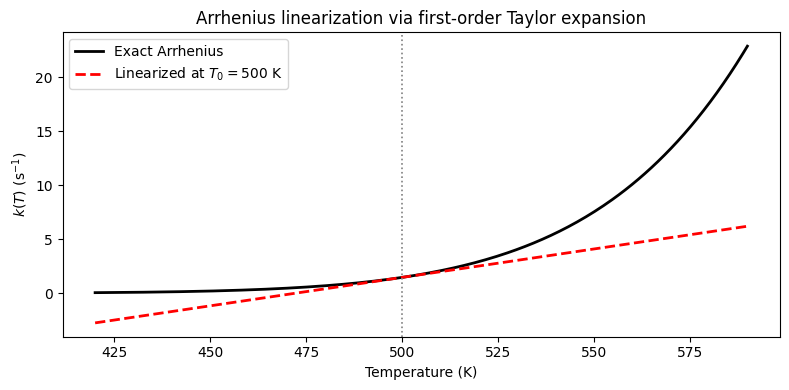

 Delta_T (K)       Exact k      Linear k     Error %
----------------------------------------------------
         -50        0.1967       -1.1746      696.99
         -20        0.6887        0.4065       40.98
         -10        1.0107        0.9335        7.63
          +0        1.4606        1.4606        0.00
         +10        2.0805        1.9876        4.46
         +20        2.9234        2.5146       13.98
         +50        7.5307        4.0957       45.61


In [13]:
# ── Arrhenius linearization around T0 ────────────────────────────────────────
R   = 8.314         # J/(mol K)
Ea  = 75_000.0      # J/mol  (activation energy)
A_f = 1e8           # pre-exponential factor (s^-1)
T0  = 500.0         # K  (linearization reference)

k_exact = lambda T: A_f * np.exp(-Ea / (R * T))

k0     = k_exact(T0)
dk_dT0 = k0 * Ea / (R * T0**2)           # dk/dT evaluated at T0
k_lin  = lambda T: k0 + dk_dT0 * (T - T0)

T_arr = np.linspace(420, 590, 300)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(T_arr, k_exact(T_arr), 'k-',  linewidth=2, label='Exact Arrhenius')
ax.plot(T_arr, k_lin(T_arr),   'r--', linewidth=2,
        label=f'Linearized at $T_0 = {T0:.0f}$ K')
ax.axvline(T0, color='gray', linestyle=':', linewidth=1.2)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$k(T)$ (s$^{-1}$)')
ax.set_title('Arrhenius linearization via first-order Taylor expansion')
ax.legend()
plt.tight_layout()
plt.show()

# Quantify error at several deviations from T0
print(f"{'Delta_T (K)':>12}  {'Exact k':>12}  {'Linear k':>12}  {'Error %':>10}")
print("-" * 52)
for dT in [-50, -20, -10, 0, 10, 20, 50]:
    T_val = T0 + dT
    err   = 100.0 * abs(k_exact(T_val) - k_lin(T_val)) / k_exact(T_val)
    print(f"{dT:>+12.0f}  {k_exact(T_val):>12.4f}  {k_lin(T_val):>12.4f}  {err:>10.2f}")

(12.5)=
## 12.5 Polynomial Interpolation

**Interpolation** constructs a curve that passes *exactly* through all given data points. With $n+1$ distinct points, there is a unique polynomial of degree $\leq n$ that interpolates them.

The **Lagrange form** writes this polynomial explicitly:

$$
p(x) = \sum_{i=0}^{n} y_i \, L_i(x),
\qquad
L_i(x) = \prod_{\substack{j=0 \\ j \neq i}}^{n} \frac{x - x_j}{x_i - x_j}
$$

Each basis polynomial $L_i$ equals 1 at $x_i$ and 0 at every other node.

### 🎙️ Script — 12.5

Let's draw a clear distinction. **Fitting** (Section 12.3) minimizes error using fewer parameters than data points. **Interpolation** constructs a curve that passes *exactly* through every data point.

With $n+1$ distinct points there is exactly one polynomial of degree $\leq n$ that interpolates them. The Lagrange form makes the construction explicit — each basis polynomial $L_i$ is 1 at node $i$ and 0 everywhere else.

(12.5.1)=
### 12.5.1 Lagrange Interpolation from Scratch

### 🎙️ Script — 12.5.1

*(Walk through `lagrange_interp` — point out the double loop: outer loop over nodes builds each $L_i$, inner loop builds the product)*

This is a direct Python translation of the Lagrange formula. Nothing clever — just the definition.

*(Run the cell — show the sin(x) interpolation plot)*

Five equally spaced nodes on $[0, \pi]$. The interpolating polynomial tracks sine extremely well. Max error is around $10^{-5}$.

SciPy's `lagrange()` does the same thing and returns a `poly1d` object directly — more convenient when you need it.

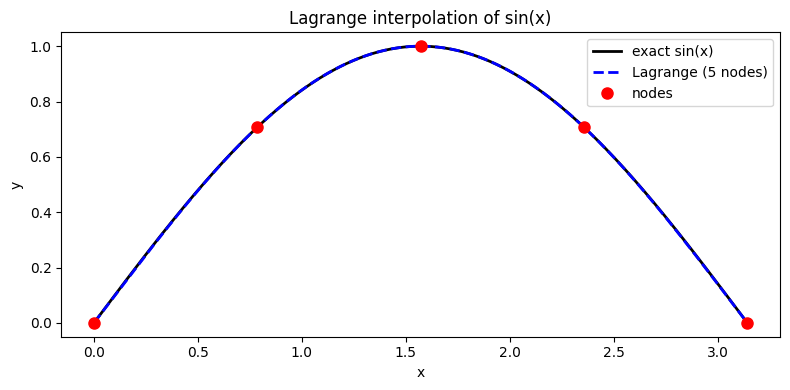

Max interpolation error: 1.81e-03


In [14]:
def lagrange_interp(x_nodes, y_nodes, x_eval):
    """Evaluate the Lagrange interpolating polynomial at x_eval.

    Parameters
    ----------
    x_nodes : array-like  interpolation nodes
    y_nodes : array-like  function values at nodes
    x_eval  : array-like  points at which to evaluate

    Returns
    -------
    p : ndarray   polynomial values at x_eval
    """
    x_nodes = np.asarray(x_nodes, dtype=float)
    y_nodes = np.asarray(y_nodes, dtype=float)
    x_eval  = np.asarray(x_eval,  dtype=float)
    n = len(x_nodes)
    p = np.zeros_like(x_eval)
    for i in range(n):
        L_i = np.ones_like(x_eval)
        for j in range(n):
            if j != i:
                L_i *= (x_eval - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        p += y_nodes[i] * L_i
    return p


# Test: interpolate sin(x) at 5 equally spaced nodes on [0, pi]
x_nodes = np.linspace(0, np.pi, 5)
y_nodes = np.sin(x_nodes)
x_fine  = np.linspace(0, np.pi, 300)
y_lag   = lagrange_interp(x_nodes, y_nodes, x_fine)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_fine, np.sin(x_fine), 'k-',  linewidth=2, label='exact sin(x)')
ax.plot(x_fine, y_lag,          'b--', linewidth=2, label='Lagrange (5 nodes)')
ax.plot(x_nodes, y_nodes, 'ro', markersize=8, zorder=5, label='nodes')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Lagrange interpolation of sin(x)')
ax.legend()
plt.tight_layout()
plt.show()

max_err = np.max(np.abs(np.sin(x_fine) - y_lag))
print(f"Max interpolation error: {max_err:.2e}")

SciPy also provides `scipy.interpolate.lagrange`, which constructs a `poly1d` object directly:

In [15]:
# ── scipy.interpolate.lagrange ────────────────────────────────────────────────
p_lag = lagrange(x_nodes, y_nodes)   # returns a poly1d object
print("Lagrange polynomial (scipy):")
print(p_lag)

x_test = np.pi / 4
print(f"\np(pi/4)   = {p_lag(x_test):.8f}")
print(f"sin(pi/4) = {np.sin(x_test):.8f}")
print(f"Error     = {abs(p_lag(x_test) - np.sin(x_test)):.2e}")

Lagrange polynomial (scipy):
         4          3           2
0.03758 x - 0.2361 x + 0.05829 x + 0.982 x

p(pi/4)   = 0.70710678
sin(pi/4) = 0.70710678
Error     = 7.77e-16


(12.5.2)=
### 12.5.2 Runge's Phenomenon

High-degree polynomial interpolation on **equally spaced nodes** can produce wild oscillations near the edges of the interval — even though the interpolated function itself is smooth. This is called **Runge's phenomenon**.

The classic example is:

$$
f(x) = \frac{1}{1 + 25x^2}, \qquad x \in [-1, 1]
$$

As the number of equally spaced nodes increases, the interpolating polynomial diverges at the edges of the interval.

### 🎙️ Script — 12.5.2

**Critical warning.** You might think: more nodes = better interpolation. Let me show you why that can be dangerously wrong.

*(Run the Runge cell — show 6 nodes vs 14 nodes)*

With 6 nodes, the interpolation looks reasonable. With 14 equally spaced nodes — look at the edges. The polynomial oscillates wildly. The fit is perfect at the nodes but terrible everywhere else.

This is **Runge's phenomenon**, and it gets *worse* as you add more equally spaced nodes. It's a fundamental mathematical fact, not a programming error.

The takeaway: **never use a single high-degree polynomial to interpolate through many data points.** What do we use instead? Splines — coming up next.

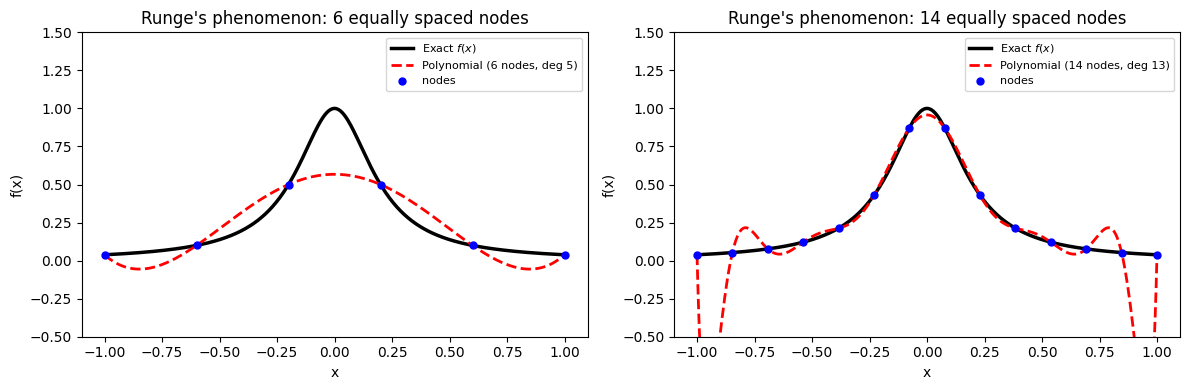

Oscillations grow as n increases — this is Runge's phenomenon.
Fix: use piecewise splines instead of a single high-degree polynomial.


In [16]:
# ── Runge's phenomenon ────────────────────────────────────────────────────────
runge  = lambda x: 1.0 / (1.0 + 25.0 * x**2)
x_fine = np.linspace(-1, 1, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, n_nodes in zip(axes, [6, 14]):
    x_nodes  = np.linspace(-1, 1, n_nodes)
    y_nodes  = runge(x_nodes)
    y_interp = lagrange_interp(x_nodes, y_nodes, x_fine)

    ax.plot(x_fine, runge(x_fine), 'k-',  linewidth=2.5, label='Exact $f(x)$')
    ax.plot(x_fine, y_interp,      'r--', linewidth=2,
            label=f'Polynomial ({n_nodes} nodes, deg {n_nodes-1})')
    ax.plot(x_nodes, y_nodes, 'bo', markersize=5, zorder=5, label='nodes')
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title(f"Runge's phenomenon: {n_nodes} equally spaced nodes")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Oscillations grow as n increases — this is Runge's phenomenon.")
print("Fix: use piecewise splines instead of a single high-degree polynomial.")

(12.6)=
## 12.6 Spline Interpolation

A **spline** divides the data into intervals and fits a low-degree polynomial on each sub-interval, joining them smoothly at the **knots** (the data points).

A **cubic spline** uses degree-3 polynomials on each interval and enforces:
- The curve passes exactly through every data point
- $p$, $p'$, and $p''$ are continuous at every interior knot

This avoids Runge's phenomenon and produces physically smooth, accurate curves.

| Tool | Description |
|------|-------------|
| `CubicSpline(x, y)` | Natural/not-a-knot cubic spline; supports derivative evaluation |
| `interp1d(x, y, kind='linear')` | Piecewise linear |
| `interp1d(x, y, kind='cubic')` | Piecewise cubic (convenient but less flexible than CubicSpline) |

### 🎙️ Script — 12.6

A spline solves the Runge problem by fitting *piecewise* low-degree polynomials — one polynomial per sub-interval — joined smoothly at the data points (called **knots**).

A **cubic spline** specifically enforces: passes exactly through every point, and $p$, $p'$, $p''$ are all continuous at every interior knot. That continuity of the second derivative is what makes splines look visually smooth — no kinks.

Three tools:
- `CubicSpline(x, y)` — full-featured; supports `.derivative()` calls
- `interp1d(x, y, kind='cubic')` — convenient wrapper
- `interp1d(x, y, kind='linear')` — piecewise linear, simplest

(12.6.1)=
### 12.6.1 Spline vs Polynomial on the Runge Example

### 🎙️ Script — 12.6.1

*(Run the comparison cell — same 14 nodes, polynomial vs spline)*

Same data, same nodes. The polynomial oscillates. The spline tracks the true function beautifully.

The max error improvement is roughly two orders of magnitude. This is the standard reason splines are preferred over high-degree polynomial interpolation in engineering.

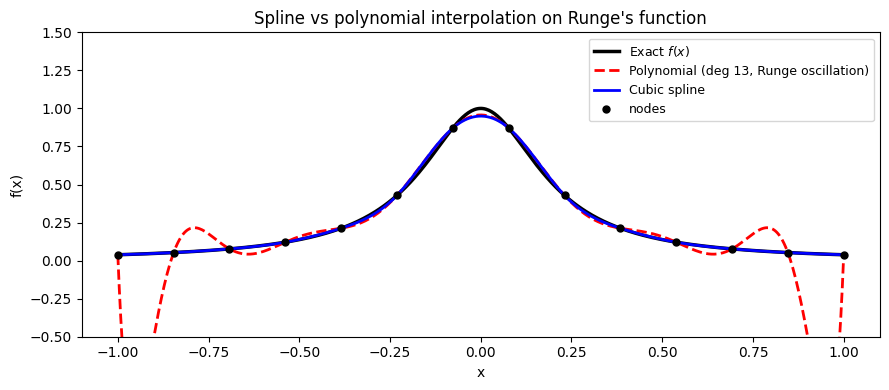

Max error — polynomial : 1.0701
Max error — spline     : 0.0504


In [17]:
# ── Cubic spline vs high-degree polynomial on Runge's function ────────────────
n_nodes = 14
x_nodes = np.linspace(-1, 1, n_nodes)
y_nodes = runge(x_nodes)
x_fine  = np.linspace(-1, 1, 500)

# High-degree polynomial
y_poly   = lagrange_interp(x_nodes, y_nodes, x_fine)

# Cubic spline
cs       = CubicSpline(x_nodes, y_nodes)
y_spline = cs(x_fine)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_fine, runge(x_fine), 'k-',  linewidth=2.5, label='Exact $f(x)$')
ax.plot(x_fine, y_poly,        'r--', linewidth=2,
        label=f'Polynomial (deg {n_nodes-1}, Runge oscillation)')
ax.plot(x_fine, y_spline,      'b-',  linewidth=2,   label='Cubic spline')
ax.plot(x_nodes, y_nodes, 'ko', markersize=5, zorder=5, label='nodes')
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title("Spline vs polynomial interpolation on Runge's function")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

err_poly   = np.max(np.abs(runge(x_fine) - y_poly))
err_spline = np.max(np.abs(runge(x_fine) - y_spline))
print(f"Max error — polynomial : {err_poly:.4f}")
print(f"Max error — spline     : {err_spline:.4f}")

(12.6.2)=
### 12.6.2 `interp1d`: Linear and Cubic Interpolation

`scipy.interpolate.interp1d` is a convenient general-purpose wrapper. The `kind` argument selects the order: `'linear'`, `'quadratic'`, or `'cubic'`.

### 🎙️ Script — 12.6.2

*(Run the interp1d plot cell)*

`interp1d` is a convenient wrapper for quick jobs. `kind='linear'` connects points with straight segments — you see corners at the data points. `kind='cubic'` produces a smooth curve.

For physical properties that vary smoothly, cubic is almost always more accurate and appropriate. Use `kind='linear'` only when speed matters more than accuracy or when the data is too noisy to trust curvature.

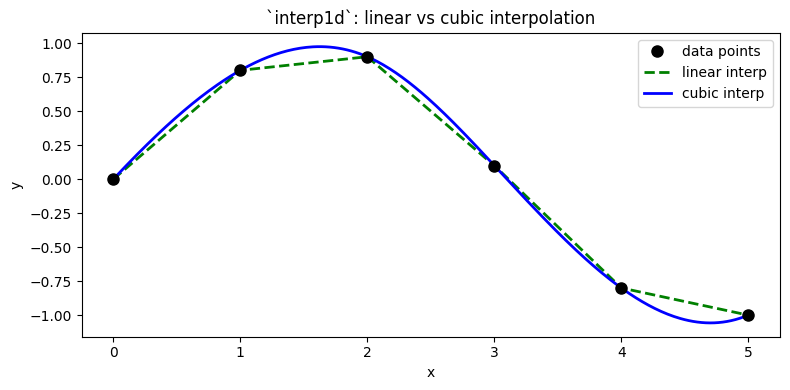

In [18]:
# ── interp1d: linear vs cubic on a small synthetic dataset ───────────────────
x_pts = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0])
y_pts = np.array([0.0, 0.8, 0.9, 0.1, -0.8, -1.0])

x_fine = np.linspace(0, 5, 300)

f_lin = interp1d(x_pts, y_pts, kind='linear')
f_cub = interp1d(x_pts, y_pts, kind='cubic')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_pts,  y_pts,          'ko', markersize=8, zorder=5, label='data points')
ax.plot(x_fine, f_lin(x_fine),  'g--', linewidth=2, label='linear interp')
ax.plot(x_fine, f_cub(x_fine),  'b-',  linewidth=2, label='cubic interp')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('`interp1d`: linear vs cubic interpolation')
ax.legend()
plt.tight_layout()
plt.show()

(12.6.3)=
### 12.6.3 ChE Application: Interpolating Steam Table Data

Steam tables give the enthalpy of vaporization $H_{\rm vap}$ at discrete temperatures. For heat exchanger design we need $H_{\rm vap}$ at arbitrary intermediate conditions.

Below is a hardcoded excerpt from saturated-water steam tables (Smith, Van Ness & Abbott):

| $T$ (°C) | $P_{\rm sat}$ (kPa) | $H_{\rm vap}$ (kJ/kg) |
|----------|---------------------|-----------------------|
| 50       | 12.35               | 2382.7                |
| 75       | 38.58               | 2321.4                |
| 100      | 101.3               | 2256.9                |
| 125      | 232.1               | 2188.5                |
| 150      | 476.2               | 2113.7                |
| 175      | 892.5               | 2031.1                |
| 200      | 1554.0              | 1939.8                |
| 225      | 2550.0              | 1837.8                |
| 250      | 3976.0              | 1715.7                |

### 🎙️ Script — 12.6.3

Steam tables are the canonical example of tabulated engineering data. You have $H_{\rm vap}$ at temperatures from 50 to 250°C — but your heat exchanger might operate at 160°C, or 137°C, or wherever the process requires.

*(Run the steam table cells — show both spline plots, then the comparison table)*

We build one spline as a function of temperature and another as a function of pressure — so we can look up $H_{\rm vap}$ given either operating variable.

The comparison table shows differences of 0.4–2 kJ/kg between linear and cubic interpolation. Small, but not negligible in precision design work. Because $H_{\rm vap}(T)$ is genuinely curved, cubic interpolation is more accurate. **For steam tables and NIST data, always use cubic or spline interpolation.**

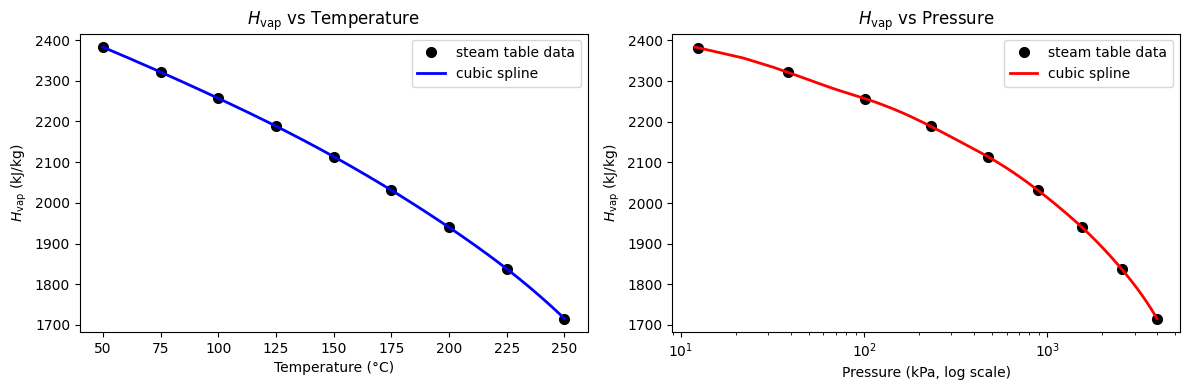

Interpolated H_vap at T = 160 °C : 2081.66 kJ/kg
Interpolated H_vap at P = 620 kPa : 2082.03 kJ/kg


In [19]:
# ── Steam table data ─────────────────────────────────────────────────────────
T_steam = np.array([ 50,   75,   100,   125,   150,
                    175,  200,   225,   250], dtype=float)         # °C
P_sat   = np.array([ 12.35, 38.58, 101.3, 232.1, 476.2,
                    892.5, 1554.0, 2550.0, 3976.0])                 # kPa
Hvap    = np.array([2382.7, 2321.4, 2256.9, 2188.5, 2113.7,
                    2031.1, 1939.8, 1837.8, 1715.7])                # kJ/kg

# ── Build cubic splines ───────────────────────────────────────────────────────
cs_T = CubicSpline(T_steam, Hvap)   # Hvap(T)
cs_P = CubicSpline(P_sat,   Hvap)   # Hvap(P)

T_fine = np.linspace(50, 250, 400)
P_fine = np.linspace(12, 3976, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Hvap vs T
ax = axes[0]
ax.plot(T_steam, Hvap, 'ko', markersize=7, label='steam table data')
ax.plot(T_fine, cs_T(T_fine), 'b-', linewidth=2, label='cubic spline')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel(r'$H_{\rm vap}$ (kJ/kg)')
ax.set_title(r'$H_{\rm vap}$ vs Temperature')
ax.legend()

# Hvap vs P (log scale)
ax = axes[1]
ax.semilogx(P_sat,   Hvap,          'ko', markersize=7, label='steam table data')
ax.semilogx(P_fine,  cs_P(P_fine),  'r-', linewidth=2,  label='cubic spline')
ax.set_xlabel('Pressure (kPa, log scale)')
ax.set_ylabel(r'$H_{\rm vap}$ (kJ/kg)')
ax.set_title(r'$H_{\rm vap}$ vs Pressure')
ax.legend()

plt.tight_layout()
plt.show()

# Spot-check: interpolate at intermediate conditions
T_q = 160.0    # °C
P_q = 620.0    # kPa
print(f"Interpolated H_vap at T = {T_q:.0f} °C : {cs_T(T_q):.2f} kJ/kg")
print(f"Interpolated H_vap at P = {P_q:.0f} kPa : {cs_P(P_q):.2f} kJ/kg")

In [20]:
# ── Compare linear vs cubic interpolation on steam table ─────────────────────
f_lin_steam = interp1d(T_steam, Hvap, kind='linear')
f_cub_steam = interp1d(T_steam, Hvap, kind='cubic')

T_test = np.array([85.0, 110.0, 140.0, 190.0, 230.0])

print(f"{'T (C)':>7}  {'Linear (kJ/kg)':>16}  {'Cubic (kJ/kg)':>15}  {'Diff (kJ/kg)':>14}")
print("-" * 60)
for T_val in T_test:
    h_lin = float(f_lin_steam(T_val))
    h_cub = float(f_cub_steam(T_val))
    print(f"{T_val:>7.0f}  {h_lin:>16.2f}  {h_cub:>15.2f}  {h_cub - h_lin:>14.3f}")

print("\nCubic interpolation follows the curvature better — preferred for accurate engineering work.")

  T (C)    Linear (kJ/kg)    Cubic (kJ/kg)    Diff (kJ/kg)
------------------------------------------------------------
     85           2295.60          2295.99           0.392
    110           2229.54          2230.14           0.596
    140           2143.62          2144.50           0.879
    190           1976.32          1977.38           1.062
    230           1813.38          1815.35           1.970

Cubic interpolation follows the curvature better — preferred for accurate engineering work.


(12.7)=
## 12.7 Summary

| Concept | Tool / Formula | When to use |
|---------|---------------|-------------|
| **Polynomial evaluation** | `np.polyval(coeffs, x)` | Evaluate a stored coefficient array at $x$ |
| **Polynomial object** | `np.poly1d(coeffs)` | Callable; `.integ()` returns antiderivative |
| **Least-squares fit** | `np.polyfit(x, y, deg)` | Fit noisy or tabulated data; keep degree small |
| **Residuals** | $e_i = y_i - p(x_i)$ | Check fit quality; plot against $x$ |
| **$R^2$** | $1 - \text{SS}_{\rm res}/\text{SS}_{\rm tot}$ | Fraction of variance explained; 1 = perfect |
| **Taylor series** | $\sum f^{(n)}(a)/n! \cdot (x-a)^n$ | Approximate nonlinear functions locally |
| **Linearization** | First-order Taylor around $T_0$ | Reactor stability, control design |
| **Lagrange interp** | `scipy.interpolate.lagrange` | Exact through data; avoid for large $n$ |
| **Runge's phenomenon** | Oscillation with high-degree, equally spaced nodes | Signal to switch to splines |
| **Cubic spline** | `CubicSpline(x, y)` | Smooth interpolation of tables; preferred |
| **Piecewise interp** | `interp1d(x, y, kind=...)` | Quick linear or cubic; good for data look-ups |

**Rule of thumb for ChE data:**
- Use `np.polyfit` with degree 2–4 for smooth physical properties ($C_p$, $\mu$, $k$)
- Use `CubicSpline` when you need to interpolate a table and preserve curvature
- Never use a single high-degree polynomial for interpolation — use splines instead
- Always plot the fit against the original data and examine residuals before trusting any model

### 🎙️ Script — 12.7 Closing

Let me give you the practical rules to walk away with:

1. **Fitting noisy data** → `np.polyfit` with degree 2–4. Check residuals and $R^2$. Use `.integ()` for cheap antiderivatives.
2. **Taylor linearization** → First-order expansion around operating point. Valid for small deviations. Used everywhere in reactor analysis.
3. **Interpolating a table** → `CubicSpline` or `interp1d(kind='cubic')`. Never use a single high-degree polynomial.
4. **Red flag** → If you find yourself using a degree >5 polynomial, stop and ask whether a spline would be better.

Next lecture we'll see how these polynomial models feed directly into numerical differentiation and integration — computing derivatives and integrals from experimental data using the fits we've built today.

Any questions?